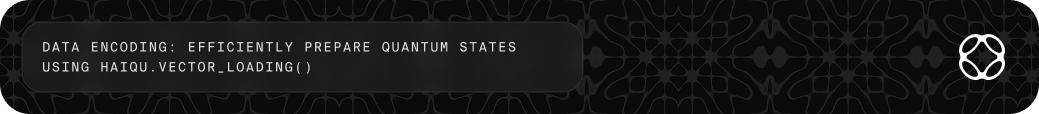

Use `haiqu.vector_loading()` to generate an arbitrary quantum state from a vector of amplitudes.

- For a 12-qubit sin wave, traditional amplitude encoding requires 4083 CNOT gates and 4083 two-qubit gate depth.
- Haiqu's method prepares the same state with 21 CNOT gates **(194.4x improvement)** and 11 two-qubit gate depth **(371.2x improvement)**.

### `haiqu.vector_loading()`

- **What does it do?** Vector loading prepares a quantum state, which amplitudes match a given data vector.
- **How do I use it?** Pass a real or complex vector to create a data loading job, then retrieve results with `job.result()`.
- **What are the options?** Optional parameters include various hyperparameters for circuit synthesis such as `num_layers`, `truncation_cutoff` and `fine_tuning_iterations`.
- **Which option do you recommend?** Start with the default settings for basic use cases. Observe the state `fidelity` returned by the job result and increase number of layers and fine tuning iterations if necessary to achieve a better precision.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, create a desired quantum state.

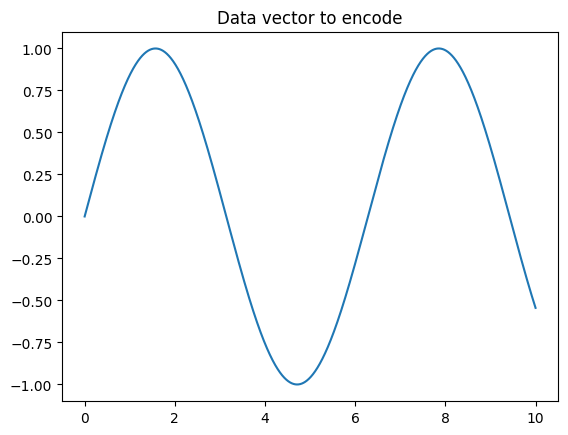

In [1]:
import qiskit
import numpy as np
import pandas as pd
from haiqu.sdk import haiqu
import matplotlib.pyplot as plt
from qiskit.circuit.library import StatePreparation

haiqu.login()
haiqu.init("Vector Loading Tutorial")

# we load a sin wave on 12 qubits
num_qubits = 12
interval = np.linspace(0, 10, 2**num_qubits)
data = np.sin(interval)

plt.plot(interval, data)
plt.title("Data vector to encode")
plt.show()

## Run benchmark scenarios

Prepare a quantum state with Qiskit's default and Haiqu's methods

In [2]:
# Scenario 1: standard method
circuit_qiskit = qiskit.QuantumCircuit(num_qubits, name="Qiskit")
circuit_qiskit.compose(StatePreparation(data, normalize=True), inplace=True)

# Scenario 2: Haiqu vector loading
circuit_haiqu = qiskit.QuantumCircuit(num_qubits, name="Haiqu")
vector_job = haiqu.vector_loading(data=data)
state_gate = vector_job.result()
circuit_haiqu.compose(state_gate, inplace=True)
print(f"Haiqu state is loaded with fidelity: {vector_job.info['fidelity']:.3f}")

Haiqu state is loaded with fidelity: 1.000


Haiqu's vector loading significantly outperforms standard methods as shown in the comparison table below:

In [3]:
# we consider an ideal device with all-to-all connectivity
device_ideal = haiqu.get_device("aer_simulator")

circuit_qiskit_transpiled = haiqu.transpile(circuit_qiskit, device=device_ideal)

circuit_haiqu_transpiled = haiqu.transpile(circuit_haiqu, device=device_ideal)

haiqu.compare_metrics(circuit_qiskit_transpiled, circuit_haiqu_transpiled)

CIRCUIT,Qiskit-on-aer_simulator,Haiqu-on-aer_simulator
QUBITS,12,12
NUM PARAMETERS,0,0
DEPTH,8167,23
2-Q GATES DEPTH,4083,11
1-Q GATES,4095,53
2-Q GATES,4083,21
OTHER GATES,0,0
GATES TOTAL,8178,74
OTHER OPERATIONS,0,0
INSTRUCTIONS TOTAL,8178,74


> **💡 Good to Know:** Vector loading method is approximate for an arbitrary quantum state, it performs better for more smooth input data vector.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

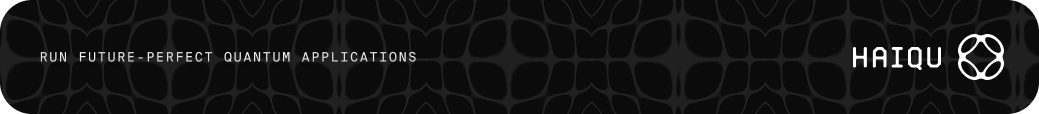